# LPB method comparison at 90% target coverage

This notebook reads one or more merged CSV/TSV result files, keeps only the **90% target coverage** rows, and compares:

- **Static** (`optimized`)
- **Locally adaptive** (`adaptive_optimized`)
- **Random** (`random_adaptive_optimized`)
- **DAPRO**

For each requested metric, it creates a publication-ready boxplot and an OpenReview-compatible Markdown table:

1. Coverage rate
2. Signed coverage-rate deviation from the 90% target
3. Coverage variance
4. LPB variance (`size`)
5. Mean weight

**Variance figure convention.** A method's sample variance is one scalar, so a literal boxplot of that scalar is not defined. The variance figures therefore show the distribution of per-replicate squared deviations from the method mean. The tables report the unbiased across-replicate sample variance (`ddof=1`), matching the convention in the accompanying analysis notebooks.


In [3]:
from pathlib import Path
import glob
import os
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


# Make the notebook work from either the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# -----------------------------------------------------------------------------
# INPUT CONFIGURATION
# -----------------------------------------------------------------------------
# Option A: list files directly.
CSV_PATHS = [
    # PROJECT_ROOT / "results" / "merged_calibration_dfs" / "experiment" / "all_df.csv",
]

# Option B: put the result files in results_for_rebuttal/ or edit this glob.
CSV_GLOBS = [
    str(PROJECT_ROOT / "results"/ "merged_calibration_dfs"/\
        "dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify_20.0_3000_0.56_10.0" / "*.csv"),
    str(PROJECT_ROOT / "results" / "*.tsv"),
]

# Optional command-line/Jupyter override, useful for reproducible execution:
#   LPB_CSV_PATHS="/path/a.csv:/path/b.csv" jupyter nbconvert --execute ...
env_paths = [p for p in os.environ.get("LPB_CSV_PATHS", "").split(os.pathsep) if p]
if env_paths:
    CSV_PATHS = [Path(p) for p in env_paths]
    CSV_GLOBS = []

TARGET_COVERAGE = 0.90
TARGET_ATOL = 5e-4
DEVIATION_MODE = "signed"  # This notebook reports coverage - target in percentage points.
ALLOW_MULTIPLE_RAW_NAMES_PER_METHOD = False

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "figures" / "lpb_90pct_method_metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METHOD_CANDIDATES = {
    "Static": [
        "static",
        "optimized",
        "static_optimized",
        "calibration_optimized_allocation",
        "calibration_static_optimized_allocation",
    ],
    "Locally adaptive": [
        "locally_adaptive",
        "adaptive_optimized",
        "locally_adaptive_optimized",
        "calibration_adaptive_optimized_allocation",
        "calibration_locally_adaptive_optimized_allocation",
    ],
    "Random": [
        "random_adaptive_optimized",
        "calibration_random_adaptive_optimized",
        "calibration_random_adaptive_optimized_allocation",
    ],
    "DAPRO": [
        "dapro",
        "calibration_projected_optimization_platt_prob_allocation",
        "calibration_projected_optimization_platt_prob_n1_100_allocation",
    ],
}
METHOD_ORDER = list(METHOD_CANDIDATES)

sns.set_theme(style="whitegrid", context="talk")
METHOD_PALETTE = dict(zip(METHOD_ORDER, sns.color_palette("colorblind", len(METHOD_ORDER))))

print(f"Target coverage: {TARGET_COVERAGE:.0%}")
print(f"Figures and tables will be written to: {OUTPUT_DIR}")

Target coverage: 90%
Figures and tables will be written to: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics


## Load, normalize, and validate the result files

The loader auto-detects comma- or tab-separated files. Coverage and target coverage may be stored as fractions (`0.90`) or percentages (`90`). Exact duplicate rows are removed. Rows are treated as distinct replicates by `(source file, seed)` so repeated seed numbers in different files are not accidentally collapsed.


In [4]:
def _resolve_input_paths(csv_paths, csv_globs):
    resolved = []
    for path in csv_paths:
        resolved.append(Path(path).expanduser().resolve())
    for pattern in csv_globs:
        resolved.extend(Path(p).resolve() for p in glob.glob(pattern, recursive=True))
    # Stable de-duplication.
    unique = []
    seen = set()
    for path in resolved:
        if path not in seen:
            seen.add(path)
            unique.append(path)
    missing = [path for path in unique if not path.exists()]
    if missing:
        raise FileNotFoundError("Input files not found:\n" + "\n".join(map(str, missing)))
    if not unique:
        raise FileNotFoundError(
            "No CSV/TSV files were found. Add paths to CSV_PATHS, edit CSV_GLOBS, "
            "or set the LPB_CSV_PATHS environment variable."
        )
    return unique


def _read_delimited(path):
    # sep=None with the Python engine detects both commas and tabs.
    try:
        return pd.read_csv(path, sep=None, engine="python")
    except Exception as exc:
        raise ValueError(f"Could not parse {path}: {exc}") from exc


def _coerce_fraction(series, column_name):
    text = series.astype(str).str.strip()
    has_percent = text.str.endswith("%")
    numeric = pd.to_numeric(text.str.rstrip("%"), errors="coerce")
    numeric.loc[has_percent] = numeric.loc[has_percent] / 100.0
    finite = numeric[np.isfinite(numeric)]
    if not finite.empty and finite.quantile(0.95) > 1.5:
        numeric = numeric / 100.0
    return numeric


def _normalize_method_name(value):
    value = str(value).strip().lower()
    value = re.sub(r"[^a-z0-9]+", "_", value).strip("_")
    return value


input_paths = _resolve_input_paths(CSV_PATHS, CSV_GLOBS)
frames = []
for path in input_paths:
    frame = _read_delimited(path)
    frame["source_file"] = path.name
    frame["source_path"] = str(path)
    frames.append(frame)

raw_df = pd.concat(frames, ignore_index=True, sort=False)
rows_before = len(raw_df)
raw_df = raw_df.drop_duplicates().copy()
exact_duplicates_removed = rows_before - len(raw_df)

required_columns = {
    "seed", "calibration_name", "target_coverage", "coverage", "size", "mean_weight"
}
missing_columns = required_columns.difference(raw_df.columns)
if missing_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_columns)}. "
        f"Available columns: {sorted(raw_df.columns)}"
    )

raw_df["target_coverage"] = _coerce_fraction(raw_df["target_coverage"], "target_coverage")
raw_df["coverage"] = _coerce_fraction(raw_df["coverage"], "coverage")
for column in ["size", "mean_weight"]:
    raw_df[column] = pd.to_numeric(raw_df[column], errors="coerce")

available_raw_names = sorted(raw_df["calibration_name"].dropna().astype(str).unique())
available_by_normalized = {}
for raw_name in available_raw_names:
    available_by_normalized.setdefault(_normalize_method_name(raw_name), []).append(raw_name)

resolved_raw_names = {}
for display_name, candidates in METHOD_CANDIDATES.items():
    matches = []
    for candidate in candidates:
        matches.extend(available_by_normalized.get(_normalize_method_name(candidate), []))
    matches = list(dict.fromkeys(matches))
    if not matches:
        raise ValueError(
            f"Could not resolve method {display_name!r}. Candidate names: {candidates}. "
            f"Available calibration_name values: {available_raw_names}"
        )
    if len(matches) > 1 and not ALLOW_MULTIPLE_RAW_NAMES_PER_METHOD:
        raise ValueError(
            f"Method {display_name!r} matched multiple raw names: {matches}. "
            "This can mix distinct configurations. Narrow METHOD_CANDIDATES or set "
            "ALLOW_MULTIPLE_RAW_NAMES_PER_METHOD=True deliberately."
        )
    resolved_raw_names[display_name] = matches

raw_to_display = {
    raw_name: display_name
    for display_name, raw_names in resolved_raw_names.items()
    for raw_name in raw_names
}

analysis_df = raw_df.loc[
    raw_df["calibration_name"].isin(raw_to_display)
    & np.isclose(raw_df["target_coverage"], TARGET_COVERAGE, atol=TARGET_ATOL, rtol=0)
].copy()
analysis_df["Method"] = analysis_df["calibration_name"].map(raw_to_display)
analysis_df["replicate_id"] = (
    analysis_df["source_path"].astype(str) + "::seed=" + analysis_df["seed"].astype(str)
)

metric_columns = ["coverage", "size", "mean_weight"]
nonfinite_mask = ~np.isfinite(analysis_df[metric_columns].to_numpy(dtype=float)).all(axis=1)
if nonfinite_mask.any():
    bad = analysis_df.loc[nonfinite_mask, ["source_file", "seed", "Method", *metric_columns]]
    raise ValueError(f"Found non-finite metric values at the 90% target:\n{bad.to_string(index=False)}")

# Exactly one selected row per source/seed/method is required.
key_columns = ["source_path", "seed", "Method"]
duplicate_keys = analysis_df.duplicated(key_columns, keep=False)
if duplicate_keys.any():
    conflicts = analysis_df.loc[
        duplicate_keys,
        [*key_columns, "calibration_name", "target_coverage", *metric_columns],
    ].sort_values(key_columns)
    raise ValueError(
        "More than one 90%-target row exists for a source/seed/method key. "
        "Inspect aliases or duplicate experiment outputs:\n"
        + conflicts.to_string(index=False)
    )

method_counts = analysis_df.groupby("Method")["replicate_id"].nunique().reindex(METHOD_ORDER)
if method_counts.isna().any() or (method_counts == 0).any():
    raise ValueError(f"At least one requested method has no rows: {method_counts.to_dict()}")
if (method_counts < 2).any():
    warnings.warn(
        "At least one method has fewer than two replicates; sample variance will be undefined."
    )

analysis_df["coverage_pct"] = 100.0 * analysis_df["coverage"]
analysis_df["coverage_deviation_pp"] = analysis_df["coverage_pct"] - 100.0 * TARGET_COVERAGE
analysis_df["coverage_sq_deviation_pp2"] = analysis_df.groupby("Method")["coverage_pct"].transform(
    lambda values: (values - values.mean()) ** 2
)
analysis_df["lpb_sq_deviation"] = analysis_df.groupby("Method")["size"].transform(
    lambda values: (values - values.mean()) ** 2
)
analysis_df["Method"] = pd.Categorical(
    analysis_df["Method"], categories=METHOD_ORDER, ordered=True
)
analysis_df = analysis_df.sort_values(["Method", "source_file", "seed"]).reset_index(drop=True)

resolution_table = pd.DataFrame(
    {
        "Method": METHOD_ORDER,
        "calibration_name": [", ".join(resolved_raw_names[m]) for m in METHOD_ORDER],
        "Replicates": method_counts.reindex(METHOD_ORDER).astype(int).to_numpy(),
    }
)
print(f"Loaded {len(input_paths)} file(s), {len(analysis_df)} selected rows, "
      f"and removed {exact_duplicates_removed} exact duplicate row(s).")
display(resolution_table)

Loaded 1 file(s), 200 selected rows, and removed 2597 exact duplicate row(s).


,Method,calibration_name,Replicates
0,Static,calibration_optimized_allocation,50
1,Locally adaptive,calibration_adaptive_optimized_allocation,50
2,Random,calibration_random_adaptive_optimized_allocation,50
3,DAPRO,calibration_projected_optimization_platt_prob_...,50


## Plotting and OpenReview table helpers

In [5]:
def _format_number(value, digits=3, signed=False):
    if pd.isna(value):
        return "—"
    pattern = f"{{:{'+' if signed else ''}.{digits}f}}"
    return pattern.format(float(value))


def _markdown_table(table, formats):
    columns = list(table.columns)
    lines = [
        "| " + " | ".join(columns) + " |",
        "|" + "|".join("---:" if i else "---" for i in range(len(columns))) + "|",
    ]
    for _, row in table.iterrows():
        rendered = []
        for column in columns:
            value = row[column]
            formatter = formats.get(column, str)
            rendered.append(formatter(value) if callable(formatter) else formatter.format(value))
        lines.append("| " + " | ".join(rendered) + " |")
    return "\n".join(lines)


def _publish_table(title, table, formats, slug, note=None):
    markdown = _markdown_table(table, formats)
    if note:
        markdown += "\n\n" + note
    display(Markdown(f"### {title}\n\n{markdown}"))
    print("Copy this block into OpenReview:\n")
    print("```markdown")
    print(markdown)
    print("```")
    (OUTPUT_DIR / f"table_{slug}.md").write_text(markdown + "\n", encoding="utf-8")
    return markdown


def _boxplot(data, y, ylabel, title, slug, reference=None, reference_label=None):
    fig, ax = plt.subplots(figsize=(9.2, 5.6))
    sns.boxplot(
        data=data,
        x="Method",
        y=y,
        order=METHOD_ORDER,
        palette=METHOD_PALETTE,
        width=0.58,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=data,
        x="Method",
        y=y,
        order=METHOD_ORDER,
        color="black",
        alpha=0.42,
        size=3.3,
        jitter=0.18,
        ax=ax,
    )
    if reference is not None:
        ax.axhline(
            reference,
            color="dimgray",
            linestyle="--",
            linewidth=1.8,
            label=reference_label,
            zorder=0,
        )
        ax.legend(frameon=False, loc="best")
    ax.set_title(title, loc="left")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", alpha=0.30)
    ax.tick_params(axis="x", rotation=12)
    fig.tight_layout()
    png_path = OUTPUT_DIR / f"figure_{slug}.png"
    pdf_path = OUTPUT_DIR / f"figure_{slug}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")
    return fig


openreview_sections = []

## 1. Coverage rate

C:\Users\Shai1\AppData\Local\Temp\ipykernel_21976\1875473246.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


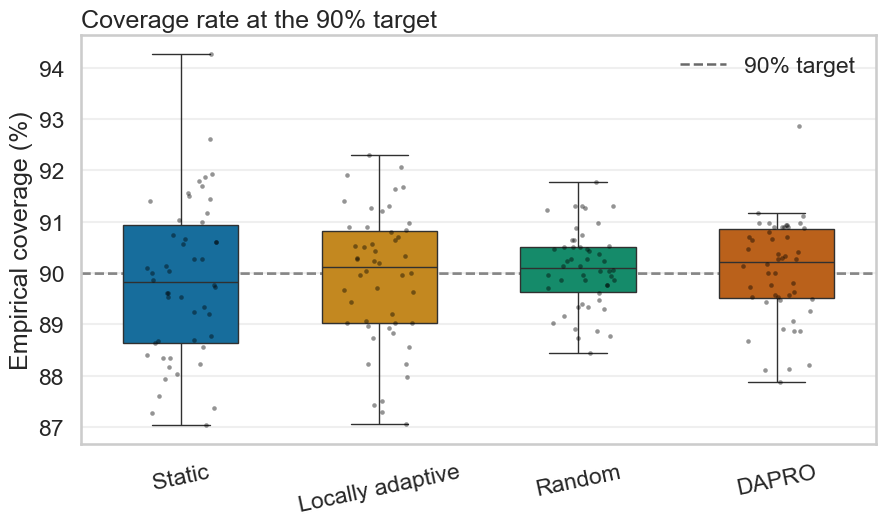

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_rate.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_rate.pdf


### Coverage rate

| Method | Mean coverage (%) | Median coverage (%) | Coverage SD (pp) | Min coverage (%) | Max coverage (%) | Replicates |
|---|---:|---:|---:|---:|---:|---:|
| Static | 89.85 | 89.82 | 1.53 | 87.03 | 94.27 | 50 |
| Locally adaptive | 89.91 | 90.12 | 1.30 | 87.07 | 92.30 | 50 |
| Random | 90.08 | 90.10 | 0.76 | 88.43 | 91.77 | 50 |
| DAPRO | 90.04 | 90.22 | 0.97 | 87.87 | 92.87 | 50 |

Target coverage is 90%. Coverage SD is across replicates in percentage points.

Copy this block into OpenReview:

```markdown
| Method | Mean coverage (%) | Median coverage (%) | Coverage SD (pp) | Min coverage (%) | Max coverage (%) | Replicates |
|---|---:|---:|---:|---:|---:|---:|
| Static | 89.85 | 89.82 | 1.53 | 87.03 | 94.27 | 50 |
| Locally adaptive | 89.91 | 90.12 | 1.30 | 87.07 | 92.30 | 50 |
| Random | 90.08 | 90.10 | 0.76 | 88.43 | 91.77 | 50 |
| DAPRO | 90.04 | 90.22 | 0.97 | 87.87 | 92.87 | 50 |

Target coverage is 90%. Coverage SD is across replicates in percentage points.
```


In [6]:
coverage_table = (
    analysis_df.groupby("Method", observed=True)["coverage_pct"]
    .agg(**{
        "Mean coverage (%)": "mean",
        "Median coverage (%)": "median",
        "Coverage SD (pp)": "std",
        "Min coverage (%)": "min",
        "Max coverage (%)": "max",
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="coverage_pct",
    ylabel="Empirical coverage (%)",
    title="Coverage rate at the 90% target",
    slug="coverage_rate",
    reference=100 * TARGET_COVERAGE,
    reference_label="90% target",
)

coverage_md = _publish_table(
    "Coverage rate",
    coverage_table,
    formats={
        "Method": str,
        "Mean coverage (%)": lambda x: _format_number(x, 2),
        "Median coverage (%)": lambda x: _format_number(x, 2),
        "Coverage SD (pp)": lambda x: _format_number(x, 2),
        "Min coverage (%)": lambda x: _format_number(x, 2),
        "Max coverage (%)": lambda x: _format_number(x, 2),
        "Replicates": lambda x: str(int(x)),
    },
    slug="coverage_rate",
    note=f"Target coverage is {100 * TARGET_COVERAGE:.0f}%. Coverage SD is across replicates in percentage points.",
)
openreview_sections.append(("Coverage rate", coverage_md))

## 2. Coverage-rate deviation from target

Deviation is **signed**: empirical coverage minus the 90% target, measured in percentage points. Positive values indicate overcoverage; negative values indicate undercoverage. The table also includes mean absolute deviation to make distance from the target explicit.


C:\Users\Shai1\AppData\Local\Temp\ipykernel_21976\1875473246.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


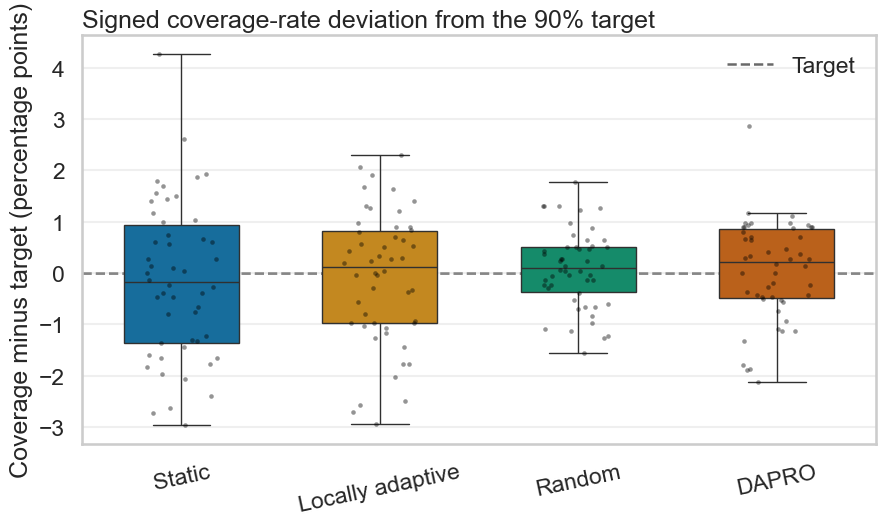

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_deviation.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_deviation.pdf


### Coverage-rate deviation from target

| Method | Mean deviation (pp) | Median deviation (pp) | Mean absolute deviation (pp) | RMSE from target (pp) | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | -0.15 | -0.18 | 1.24 | 1.52 | 50 |
| Locally adaptive | -0.09 | +0.12 | 1.05 | 1.29 | 50 |
| Random | +0.08 | +0.10 | 0.60 | 0.76 | 50 |
| DAPRO | +0.04 | +0.22 | 0.78 | 0.96 | 50 |

Deviation is empirical coverage minus 90%, in percentage points; positive values are overcoverage.

Copy this block into OpenReview:

```markdown
| Method | Mean deviation (pp) | Median deviation (pp) | Mean absolute deviation (pp) | RMSE from target (pp) | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | -0.15 | -0.18 | 1.24 | 1.52 | 50 |
| Locally adaptive | -0.09 | +0.12 | 1.05 | 1.29 | 50 |
| Random | +0.08 | +0.10 | 0.60 | 0.76 | 50 |
| DAPRO | +0.04 | +0.22 | 0.78 | 0.96 | 50 |

Deviation is empirical coverage minus 90%, in percentage points; positive values are overcoverage.
```


In [7]:
deviation_table = (
    analysis_df.groupby("Method", observed=True)["coverage_deviation_pp"]
    .agg(**{
        "Mean deviation (pp)": "mean",
        "Median deviation (pp)": "median",
        "Mean absolute deviation (pp)": lambda x: x.abs().mean(),
        "RMSE from target (pp)": lambda x: np.sqrt(np.mean(np.square(x))),
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="coverage_deviation_pp",
    ylabel="Coverage minus target (percentage points)",
    title="Signed coverage-rate deviation from the 90% target",
    slug="coverage_deviation",
    reference=0.0,
    reference_label="Target",
)

deviation_md = _publish_table(
    "Coverage-rate deviation from target",
    deviation_table,
    formats={
        "Method": str,
        "Mean deviation (pp)": lambda x: _format_number(x, 2, signed=True),
        "Median deviation (pp)": lambda x: _format_number(x, 2, signed=True),
        "Mean absolute deviation (pp)": lambda x: _format_number(x, 2),
        "RMSE from target (pp)": lambda x: _format_number(x, 2),
        "Replicates": lambda x: str(int(x)),
    },
    slug="coverage_deviation",
    note="Deviation is empirical coverage minus 90%, in percentage points; positive values are overcoverage.",
)
openreview_sections.append(("Coverage-rate deviation", deviation_md))

## 3. Coverage variance

The figure shows per-replicate squared deviations from each method's mean coverage. The table reports the unbiased sample variance across replicates in percentage-point squared.


C:\Users\Shai1\AppData\Local\Temp\ipykernel_21976\1875473246.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


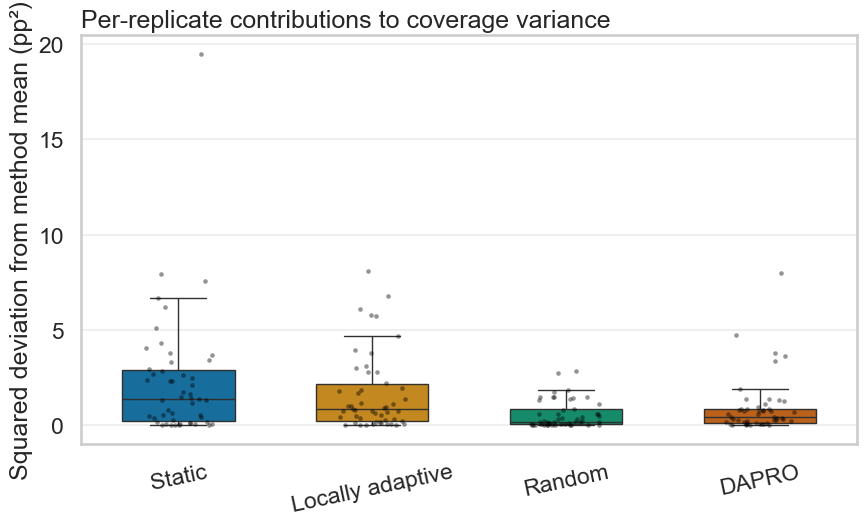

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_variance.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_coverage_variance.pdf


### Coverage variance

| Method | Coverage variance (pp²) | Coverage SD (pp) | Mean coverage (%) | Replicates |
|---|---:|---:|---:|---:|
| Static | 2.342 | 1.530 | 89.85 | 50 |
| Locally adaptive | 1.681 | 1.297 | 89.91 | 50 |
| Random | 0.576 | 0.759 | 90.08 | 50 |
| DAPRO | 0.947 | 0.973 | 90.04 | 50 |

Variance is the across-replicate unbiased sample variance (`ddof=1`) of coverage measured in percentage points.

Copy this block into OpenReview:

```markdown
| Method | Coverage variance (pp²) | Coverage SD (pp) | Mean coverage (%) | Replicates |
|---|---:|---:|---:|---:|
| Static | 2.342 | 1.530 | 89.85 | 50 |
| Locally adaptive | 1.681 | 1.297 | 89.91 | 50 |
| Random | 0.576 | 0.759 | 90.08 | 50 |
| DAPRO | 0.947 | 0.973 | 90.04 | 50 |

Variance is the across-replicate unbiased sample variance (`ddof=1`) of coverage measured in percentage points.
```


In [8]:
coverage_variance_table = (
    analysis_df.groupby("Method", observed=True)["coverage_pct"]
    .agg(**{
        "Coverage variance (pp²)": lambda x: x.var(ddof=1),
        "Coverage SD (pp)": lambda x: x.std(ddof=1),
        "Mean coverage (%)": "mean",
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="coverage_sq_deviation_pp2",
    ylabel="Squared deviation from method mean (pp²)",
    title="Per-replicate contributions to coverage variance",
    slug="coverage_variance",
)

coverage_variance_md = _publish_table(
    "Coverage variance",
    coverage_variance_table,
    formats={
        "Method": str,
        "Coverage variance (pp²)": lambda x: _format_number(x, 3),
        "Coverage SD (pp)": lambda x: _format_number(x, 3),
        "Mean coverage (%)": lambda x: _format_number(x, 2),
        "Replicates": lambda x: str(int(x)),
    },
    slug="coverage_variance",
    note="Variance is the across-replicate unbiased sample variance (`ddof=1`) of coverage measured in percentage points.",
)
openreview_sections.append(("Coverage variance", coverage_variance_md))

## 4. LPB variance

`size` is treated as the split-level mean LPB size, following the attached notebooks. The figure shows per-replicate squared deviations from each method's mean LPB size; the table reports the unbiased sample variance.


C:\Users\Shai1\AppData\Local\Temp\ipykernel_21976\1875473246.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


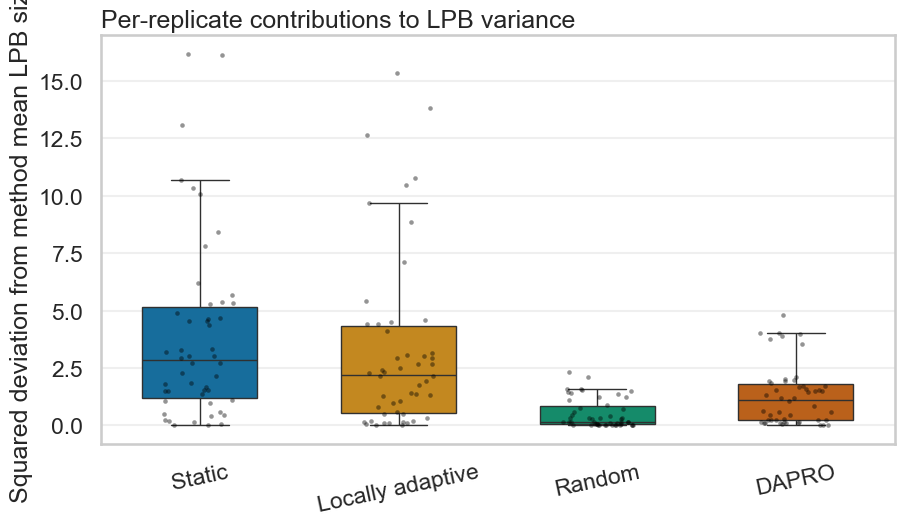

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_lpb_variance.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_lpb_variance.pdf


### LPB variance

| Method | LPB variance | LPB SD | Mean LPB size | Median LPB size | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | 3.985 | 1.996 | 7.759 | 7.791 | 50 |
| Locally adaptive | 3.369 | 1.836 | 7.590 | 7.202 | 50 |
| Random | 0.520 | 0.721 | 7.172 | 7.131 | 50 |
| DAPRO | 1.318 | 1.148 | 7.268 | 7.204 | 50 |

LPB variance is the across-replicate unbiased sample variance (`ddof=1`) of the `size` column.

Copy this block into OpenReview:

```markdown
| Method | LPB variance | LPB SD | Mean LPB size | Median LPB size | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | 3.985 | 1.996 | 7.759 | 7.791 | 50 |
| Locally adaptive | 3.369 | 1.836 | 7.590 | 7.202 | 50 |
| Random | 0.520 | 0.721 | 7.172 | 7.131 | 50 |
| DAPRO | 1.318 | 1.148 | 7.268 | 7.204 | 50 |

LPB variance is the across-replicate unbiased sample variance (`ddof=1`) of the `size` column.
```


In [9]:
lpb_variance_table = (
    analysis_df.groupby("Method", observed=True)["size"]
    .agg(**{
        "LPB variance": lambda x: x.var(ddof=1),
        "LPB SD": lambda x: x.std(ddof=1),
        "Mean LPB size": "mean",
        "Median LPB size": "median",
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="lpb_sq_deviation",
    ylabel="Squared deviation from method mean LPB size",
    title="Per-replicate contributions to LPB variance",
    slug="lpb_variance",
)

lpb_variance_md = _publish_table(
    "LPB variance",
    lpb_variance_table,
    formats={
        "Method": str,
        "LPB variance": lambda x: _format_number(x, 3),
        "LPB SD": lambda x: _format_number(x, 3),
        "Mean LPB size": lambda x: _format_number(x, 3),
        "Median LPB size": lambda x: _format_number(x, 3),
        "Replicates": lambda x: str(int(x)),
    },
    slug="lpb_variance",
    note="LPB variance is the across-replicate unbiased sample variance (`ddof=1`) of the `size` column.",
)
openreview_sections.append(("LPB variance", lpb_variance_md))

## 5. Mean weight

C:\Users\Shai1\AppData\Local\Temp\ipykernel_21976\1875473246.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


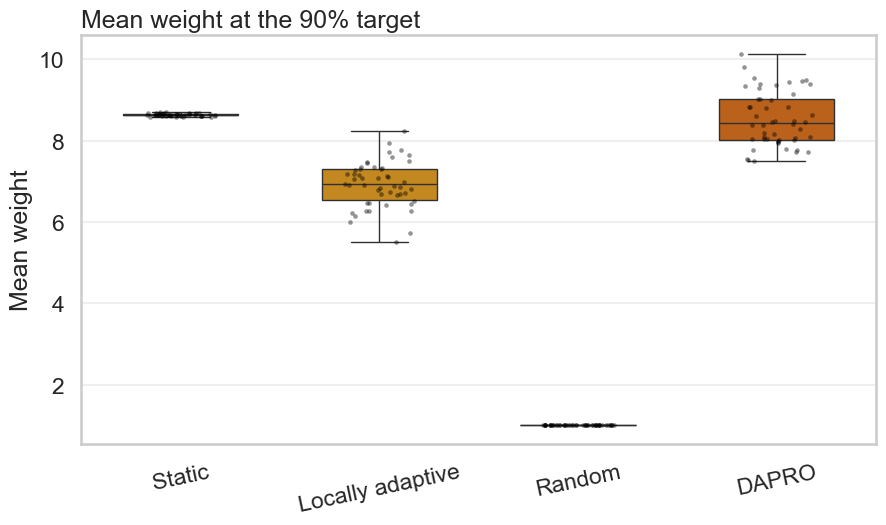

Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_mean_weight.png
Saved: C:\Users\Shai1\Documents\projects\dapro_rebuttal\notebooks\figures\lpb_90pct_method_metrics\figure_mean_weight.pdf


### Mean weight

| Method | Mean weight | Median weight | Weight SD | Min weight | Max weight | Replicates |
|---|---:|---:|---:|---:|---:|---:|
| Static | 8.640 | 8.639 | 0.029 | 8.590 | 8.699 | 50 |
| Locally adaptive | 6.930 | 6.929 | 0.560 | 5.519 | 8.234 | 50 |
| Random | 1.000 | 1.000 | 0.000 | 1.000 | 1.000 | 50 |
| DAPRO | 8.538 | 8.432 | 0.671 | 7.505 | 10.138 | 50 |

All rows are restricted to target coverage 90%.

Copy this block into OpenReview:

```markdown
| Method | Mean weight | Median weight | Weight SD | Min weight | Max weight | Replicates |
|---|---:|---:|---:|---:|---:|---:|
| Static | 8.640 | 8.639 | 0.029 | 8.590 | 8.699 | 50 |
| Locally adaptive | 6.930 | 6.929 | 0.560 | 5.519 | 8.234 | 50 |
| Random | 1.000 | 1.000 | 0.000 | 1.000 | 1.000 | 50 |
| DAPRO | 8.538 | 8.432 | 0.671 | 7.505 | 10.138 | 50 |

All rows are restricted to target coverage 90%.
```


In [10]:
mean_weight_table = (
    analysis_df.groupby("Method", observed=True)["mean_weight"]
    .agg(**{
        "Mean weight": "mean",
        "Median weight": "median",
        "Weight SD": "std",
        "Min weight": "min",
        "Max weight": "max",
        "Replicates": "count",
    })
    .reindex(METHOD_ORDER)
    .reset_index()
)

_boxplot(
    analysis_df,
    y="mean_weight",
    ylabel="Mean weight",
    title="Mean weight at the 90% target",
    slug="mean_weight",
)

mean_weight_md = _publish_table(
    "Mean weight",
    mean_weight_table,
    formats={
        "Method": str,
        "Mean weight": lambda x: _format_number(x, 3),
        "Median weight": lambda x: _format_number(x, 3),
        "Weight SD": lambda x: _format_number(x, 3),
        "Min weight": lambda x: _format_number(x, 3),
        "Max weight": lambda x: _format_number(x, 3),
        "Replicates": lambda x: str(int(x)),
    },
    slug="mean_weight",
    note=f"All rows are restricted to target coverage {100 * TARGET_COVERAGE:.0f}%.",
)
openreview_sections.append(("Mean weight", mean_weight_md))

## Export all OpenReview tables together

In [11]:
combined_markdown_parts = []
for title, markdown in openreview_sections:
    combined_markdown_parts.extend([f"### {title}", "", markdown, ""])
combined_markdown = "\n".join(combined_markdown_parts).rstrip() + "\n"
combined_path = OUTPUT_DIR / "openreview_tables.md"
combined_path.write_text(combined_markdown, encoding="utf-8")

print("Combined OpenReview Markdown:\n")
print("```markdown")
print(combined_markdown.rstrip())
print("```")
print(f"\nSaved all tables to: {combined_path}")

artifact_index = pd.DataFrame({
    "Metric": [title for title, _ in openreview_sections],
    "PNG": [str(OUTPUT_DIR / f"figure_{slug}.png") for slug in [
        "coverage_rate", "coverage_deviation", "coverage_variance", "lpb_variance", "mean_weight"
    ]],
    "PDF": [str(OUTPUT_DIR / f"figure_{slug}.pdf") for slug in [
        "coverage_rate", "coverage_deviation", "coverage_variance", "lpb_variance", "mean_weight"
    ]],
    "Markdown table": [str(OUTPUT_DIR / f"table_{slug}.md") for slug in [
        "coverage_rate", "coverage_deviation", "coverage_variance", "lpb_variance", "mean_weight"
    ]],
})
display(artifact_index)

Combined OpenReview Markdown:

```markdown
### Coverage rate

| Method | Mean coverage (%) | Median coverage (%) | Coverage SD (pp) | Min coverage (%) | Max coverage (%) | Replicates |
|---|---:|---:|---:|---:|---:|---:|
| Static | 89.85 | 89.82 | 1.53 | 87.03 | 94.27 | 50 |
| Locally adaptive | 89.91 | 90.12 | 1.30 | 87.07 | 92.30 | 50 |
| Random | 90.08 | 90.10 | 0.76 | 88.43 | 91.77 | 50 |
| DAPRO | 90.04 | 90.22 | 0.97 | 87.87 | 92.87 | 50 |

Target coverage is 90%. Coverage SD is across replicates in percentage points.

### Coverage-rate deviation

| Method | Mean deviation (pp) | Median deviation (pp) | Mean absolute deviation (pp) | RMSE from target (pp) | Replicates |
|---|---:|---:|---:|---:|---:|
| Static | -0.15 | -0.18 | 1.24 | 1.52 | 50 |
| Locally adaptive | -0.09 | +0.12 | 1.05 | 1.29 | 50 |
| Random | +0.08 | +0.10 | 0.60 | 0.76 | 50 |
| DAPRO | +0.04 | +0.22 | 0.78 | 0.96 | 50 |

Deviation is empirical coverage minus 90%, in percentage points; positive values are overc

,Metric,PNG,PDF,Markdown table
0,Coverage rate,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
1,Coverage-rate deviation,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
2,Coverage variance,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
3,LPB variance,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
4,Mean weight,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...,C:\Users\Shai1\Documents\projects\dapro_rebutt...
